# GOBAI-O2 v2.3 monthly → materialized Icechunk on Source Cooperative

Builds the Icechunk store published at
**<https://data.source.coop/fish-pace/gobai-o2/monthly>** from the single NetCDF file
that NOAA NCEI archives for GOBAI-O2 v2.3 (accession
[0259304](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:0259304)).

This one is **materialized**, not virtual: `Dataset.to_zarr` writes real Zarr v3 chunks
into the Icechunk repository, so the store is self-contained and nothing is read back
from NCEI at read time. The other pipelines in this repository store byte-range
references instead. Materializing is the right choice here because the source is a
single 12 GB contiguous, uncompressed NetCDF — there are no usable chunk boundaries to
reference, and the rechunked, Zstd-compressed copy is 5.6 GB.

| | |
|---|---|
| **Source** | `GOBAI-O2-v2.3.nc`, 12,207,313,813 bytes, NCEI accession 0259304 (version 5.5) |
| **Destination** | `fish-pace/gobai-o2/monthly` on Source Cooperative |
| **Shape** | `time: 252, pres: 58, lat: 145, lon: 360` — monthly, 2004-01 → 2024-12 |
| **Chunks** | `(14, 2, 73, 120)` ≈ 1.0 MB per chunk, Zstd |
| **Built** | 2026-08-06, snapshot `8DKFSNN3G386BXJS8X6G`, tagged `v2.3` |

## Running this notebook

`RUN_WRITE` below defaults to **False**, so the notebook runs end to end without
credentials and without touching the published store: it opens the source, builds the
metadata and encoding exactly as the build did, skips the write, and then validates the
published store against the source. That is how the committed outputs were produced.

Set `RUN_WRITE = True` to actually (re)build the store. That needs Source Cooperative
write credentials — log in first:

```bash
source-coop login --duration 1d --port 8400
```

and note that `mode="w"` replaces the whole Zarr hierarchy in a new snapshot.

In [1]:
# Dependencies. In the git repo: pip install -r requirements.txt
# Standalone (downloaded on its own from Source Cooperative), uncomment:
# !pip install -q "icechunk>=2.1" xarray zarr "dask[array]" netCDF4 h5netcdf boto3 matplotlib
#
# icechunk 2.x requires Python >= 3.12. netCDF4 (not h5netcdf) is what reads the source
# straight off NCEI's HTTPS server via the "#mode=bytes" suffix; boto3 is only used by
# the docs-mirror cell at the end.

In [2]:
import sys
# icechunk_utils.py lives at the repo root (one level up) in the git repo, or alongside
# this notebook when downloaded from Source Cooperative. Jupyter puts the notebook's own
# directory on sys.path, so a co-located copy imports as is; '..' covers the git layout.
sys.path.insert(0, '..')

import os
from datetime import datetime, timezone
from pathlib import Path

import dask
import icechunk
import xarray as xr

from icechunk_utils import open_source_icechunk_repo, get_source_credentials

print(f"icechunk={icechunk.__version__}, xarray={xr.__version__}, dask={dask.__version__}")

icechunk=2.2.2, xarray=2026.7.0, dask=2026.8.0


In [3]:
# ---------------------------------------------------------------- configuration ----
# False: run the notebook end to end without credentials, writing nothing. The store is
# still opened anonymously and validated against the source in section 6.
# True:  rebuild fish-pace/gobai-o2/monthly. Needs Source Cooperative write credentials,
#        and mode='w' replaces the whole hierarchy in a new snapshot.
RUN_WRITE = False

BUCKET = "fish-pace"
PREFIX = "gobai-o2/monthly"
BRANCH = "main"
PUBLIC_URL = f"https://data.source.coop/{BUCKET}/{PREFIX}"

# Source: NCEI accession 0259304, archive version 5.5. The accession landing page's
# "download" button currently 302-loops, but the archive filesystem path below serves
# the file directly and honors range requests.
NCEI_URL = (
    "https://www.ncei.noaa.gov/data/oceans/archive/arc0207/0259304/5.5/data/0-data/"
    "GOBAI-O2-v2.3.nc"
)

# Chunk shape of the written store, ~1.6 MB per chunk of float32.
CHUNKS = {"time": 14, "pres": 2, "lat": 73, "lon": 120}

## 1. Open the source

The source is one 12 GB NetCDF-4 file. It is **contiguous and uncompressed**, so any read
is a strided walk through the file rather than a chunk fetch.

Two ways to reach it, and the choice matters:

- **Streamed from NCEI** (the default when no local copy is found). `netCDF4` appends
  `#mode=bytes` and reads the file over HTTPS range requests — nothing is downloaded up
  front. Opening takes a few seconds and reading a single `(lat, lon)` plane about a
  second, which is fine for inspection and for the validation in section 6.
- **From a local copy**, if `$GOBAI_O2_NC` points at one (or the default scratch path
  exists). **Use this for `RUN_WRITE = True`**: writing the store reads all 12 GB in a
  strided pattern, which over HTTPS means an enormous number of range requests.

```bash
mkdir -p ~/gobai-o2-scratch
curl -o ~/gobai-o2-scratch/GOBAI-O2-v2.3.nc \
  https://www.ncei.noaa.gov/data/oceans/archive/arc0207/0259304/5.5/data/0-data/GOBAI-O2-v2.3.nc
```

The dataset stays lazy either way — `chunks=` hands the arrays to dask.

In [4]:
local_nc = Path(os.environ.get("GOBAI_O2_NC", Path.home() / "gobai-o2-scratch" / "GOBAI-O2-v2.3.nc")).expanduser()

if local_nc.is_file():
    source = str(local_nc)
    print(f"Reading the local copy: {source} ({local_nc.stat().st_size:,} bytes)")
else:
    source = f"{NCEI_URL}#mode=bytes"
    print(f"No local copy at {local_nc} — streaming from NCEI over HTTPS.")
    if RUN_WRITE:
        print("WARNING: a full write streamed over HTTPS will be very slow. Download the file first.")

# engine='netcdf4' handles both cases; h5netcdf also works for a local file but cannot
# read the '#mode=bytes' URL form.
ds = xr.open_dataset(source, chunks=CHUNKS, engine="netcdf4")
ds

No local copy at /home/jovyan/gobai-o2-scratch/GOBAI-O2-v2.3.nc — streaming from NCEI over HTTPS.


<xarray.Dataset> Size: 12GB
Dimensions:  (time: 252, pres: 58, lat: 145, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2004-01-15 2004-02-15 ... 2024-12-15
  * pres     (pres) float32 232B 2.5 10.0 20.0 ... 1.8e+03 1.9e+03 1.975e+03
  * lat      (lat) float32 580B -64.5 -63.5 -62.5 -61.5 ... 76.5 77.5 78.5 79.5
  * lon      (lon) float32 1kB 20.5 21.5 22.5 23.5 ... 376.5 377.5 378.5 379.5
Data variables:
    oxy      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    uncer    (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    temp     (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    sal      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>

## 2. Prepare CF and discovery metadata

The source carries useful per-variable descriptions but **no global attributes at all**,
and its units strings are free text (`"micromoles per kilogram"`, `"degrees Celcius"`,
`"N/A"` for salinity). The changes below:

- retain the source descriptions and provenance;
- add the authoritative GOBAI-O2 citation, DOI, creators, license and references;
- identify the coordinate axes and use CF-compatible units;
- identify oxygen, temperature and practical salinity with valid CF standard names;
- leave uncertainty without a `standard_name`, because the CF table has no exact standard
  name for this product's combined oxygen uncertainty;
- link `uncer` to `oxy` as an ancillary variable.

**Nothing here changes a data value** — these are metadata only.

The `license` attribute is **CC0 1.0**, matching `GOBAI-O2-v2.3-license.txt` as NCEI
distributes it. The 2026-08-06 build wrote CC BY 4.0 here by mistake; that was corrected
in the published store on 2026-09-17 by a metadata-only commit
(`3A41NX29VSPEXA94ES9G`), which is why the store's `history` has a second line that a
fresh build of this notebook will not reproduce.

References: [GOBAI-O2](https://www.pmel.noaa.gov/gobai/),
[NCEI Accession 0259304](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:0259304),
and [Sharp et al. (2023)](https://doi.org/10.5194/essd-15-4481-2023).

In [5]:
prepared = ds.copy(deep=False)
prepared.attrs.update(
    {
        "Conventions": "CF-1.12, ACDD-1.3",
        "title": "GOBAI-O2 v2.3: Global Gridded Monthly Ocean Interior Dissolved Oxygen",
        "summary": (
            "Monthly global fields of ocean interior dissolved oxygen, total uncertainty, "
            "temperature, and salinity produced using observations and machine learning."
        ),
        "source": (
            "GOBAI-O2 v2.3; machine-learning dissolved oxygen fields with Roemmich and "
            "Gilson (2009) temperature and salinity fields"
        ),
        "history": (
            f"{datetime.now(timezone.utc).isoformat()}: converted from GOBAI-O2-v2.3.nc "
            "to materialized Zarr v3 in Icechunk using Xarray"
        ),
        "creator_name": (
            "Jonathan D. Sharp, Andrea J. Fassbender, Brendan R. Carter, "
            "Gregory C. Johnson, John P. Dunne, Cristina Schultz"
        ),
        "creator_institution": "NOAA Pacific Marine Environmental Laboratory and collaborators",
        "citation": (
            "Sharp, J. D., Fassbender, A. J., Carter, B. R., Johnson, G. C., Schultz, C., "
            "Dunne, J. P. (2022). GOBAI-O2: A Global Gridded Monthly Dataset of Ocean "
            "Interior Dissolved Oxygen Concentrations Based on Shipboard and Autonomous "
            "Observations (NCEI Accession 0259304). NOAA NCEI. "
            "https://doi.org/10.25921/z72m-yz67"
        ),
        "doi": "10.25921/z72m-yz67",
        "license": (
            "Creative Commons Zero v1.0 Universal (CC0 1.0); source license: "
            "https://www.ncei.noaa.gov/data/oceans/archive/arc0207/0259304/5.5/data/"
            "0-data/GOBAI-O2-v2.3-license.txt"
        ),
        "references": (
            "https://www.pmel.noaa.gov/gobai/; "
            "https://doi.org/10.25921/z72m-yz67; "
            "https://doi.org/10.5194/essd-15-4481-2023"
        ),
        "product_version": "2.3",
    }
)

prepared["time"].attrs.update({"standard_name": "time", "long_name": "Time", "axis": "T"})
prepared["lat"].attrs.update(
    {"standard_name": "latitude", "long_name": "Latitude", "units": "degrees_north", "axis": "Y"}
)
prepared["lon"].attrs.update(
    {"standard_name": "longitude", "long_name": "Longitude", "units": "degrees_east", "axis": "X"}
)
prepared["pres"].attrs.update(
    {
        "standard_name": "sea_water_pressure",
        "long_name": "Sea Water Pressure",
        "units": "dbar",
        "positive": "down",
        "axis": "Z",
    }
)
prepared["oxy"].attrs.update(
    {
        "standard_name": "moles_of_oxygen_per_unit_mass_in_sea_water",
        "long_name": "Dissolved Molecular Oxygen Concentration",
        "units": "umol kg-1",
        "ancillary_variables": "uncer",
    }
)
prepared["uncer"].attrs.update(
    {"long_name": "Total Uncertainty in Dissolved Molecular Oxygen Concentration", "units": "umol kg-1"}
)
prepared["temp"].attrs.update(
    {"standard_name": "sea_water_temperature", "long_name": "Sea Water Temperature", "units": "degree_Celsius"}
)
prepared["sal"].attrs.update(
    {"standard_name": "sea_water_practical_salinity", "long_name": "Sea Water Practical Salinity", "units": "1"}
)

for name in prepared.data_vars:
    prepared[name].attrs["coordinates"] = "time pres lat lon"

prepared

<xarray.Dataset> Size: 12GB
Dimensions:  (time: 252, pres: 58, lat: 145, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2004-01-15 2004-02-15 ... 2024-12-15
  * pres     (pres) float32 232B 2.5 10.0 20.0 ... 1.8e+03 1.9e+03 1.975e+03
  * lat      (lat) float32 580B -64.5 -63.5 -62.5 -61.5 ... 76.5 77.5 78.5 79.5
  * lon      (lon) float32 1kB 20.5 21.5 22.5 23.5 ... 376.5 377.5 378.5 379.5
Data variables:
    oxy      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    uncer    (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    temp     (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    sal      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
Attributes:
    Conventions:          CF-1.12, ACDD-1.3
    title:                GOBAI-O2 v2.3: Global Gridded Monthly Ocean Interio...
    summary:              Monthly global fields of ocean interior dissolved o...
    source:               GOBAI-O2 v2.3; machine-learning dissolved oxygen fi...
    history:              2026-09-17T20:54:55.477770+00:00: converted from GO...
    creator_name:         Jonathan D. Sharp, Andrea J. Fassbender, Brendan R....
    creator_institution:  NOAA Pacific Marine Environmental Laboratory and co...
    citation:             Sharp, J. D., Fassbender, A. J., Carter, B. R., Joh...
    doi:                  10.25921/z72m-yz67
    license:              Creative Commons Zero v1.0 Universal (CC0 1.0); sou...
    references:           https://www.pmel.noaa.gov/gobai/; https://doi.org/1...
    product_version:      2.3

## 3. Build chunking and encoding programmatically

Each variable gets the subset of `CHUNKS` that matches its own dimensions; 1-D coordinate
variables are stored as a single chunk. Existing fill-value encoding is copied where the
source defines it — this source defines no explicit `_FillValue`.

`(14, 2, 73, 120)` float32 is 0.98 MB per chunk, and it is a compromise between the two
access patterns: a global map at one time and pressure touches 6 chunks, a 252-month time
series at one point and depth touches 18, and a full-depth profile at one time touches 29.
Measured anonymously from the published store, those reads take about 0.4 s, 0.8 s and
1.3 s respectively.

In [6]:
def chunks_for(variable):
    if variable.ndim <= 1:
        return variable.shape
    return tuple(min(CHUNKS.get(dim, size), size) for dim, size in zip(variable.dims, variable.shape))


encoding = {}
for name, variable in prepared.variables.items():
    variable_encoding = {"chunks": chunks_for(variable)}
    for key in ("_FillValue", "missing_value"):
        if key in ds[name].encoding:
            variable_encoding[key] = ds[name].encoding[key]
    encoding[name] = variable_encoding

encoding["time"].update(
    {
        "units": ds["time"].encoding.get("units", "days since 1950-01-01"),
        "calendar": ds["time"].encoding.get("calendar", "proleptic_gregorian"),
        "dtype": ds["time"].encoding.get("dtype", "float32"),
    }
)

dask_chunks = {dim: min(size, prepared.sizes[dim]) for dim, size in CHUNKS.items() if dim in prepared.dims}
prepared = prepared.chunk(dask_chunks)

for name, variable_encoding in encoding.items():
    print(f"{name}: dimensions={prepared[name].dims}, encoding={variable_encoding}")

oxy: dimensions=('time', 'pres', 'lat', 'lon'), encoding={'chunks': (14, 2, 73, 120)}
uncer: dimensions=('time', 'pres', 'lat', 'lon'), encoding={'chunks': (14, 2, 73, 120)}
temp: dimensions=('time', 'pres', 'lat', 'lon'), encoding={'chunks': (14, 2, 73, 120)}
sal: dimensions=('time', 'pres', 'lat', 'lon'), encoding={'chunks': (14, 2, 73, 120)}
lon: dimensions=('lon',), encoding={'chunks': (360,)}
lat: dimensions=('lat',), encoding={'chunks': (145,)}
pres: dimensions=('pres',), encoding={'chunks': (58,)}
time: dimensions=('time',), encoding={'chunks': (252,), 'units': 'days since 1950-01-01', 'calendar': 'proleptic_gregorian', 'dtype': dtype('float32')}


## 4. Open the repository on Source Cooperative

`open_source_icechunk_repo` (in `icechunk_utils.py` at the repo root) refreshes the
short-lived Source Cooperative token through the `source-coop` CLI, checks that enough
time is left to finish, and opens — or creates — the repository. Skipped entirely unless
`RUN_WRITE` is set, so the rest of the notebook needs no credentials.

In [7]:
repo = None
if RUN_WRITE:
    repo, storage, source_creds, time_left = open_source_icechunk_repo(
        bucket=BUCKET, prefix=PREFIX, min_minutes_left=90
    )
    if repo is None:
        raise RuntimeError("Not enough time left on the Source Cooperative token; log in again.")
else:
    print("RUN_WRITE is False — not opening a writable session.")

RUN_WRITE is False — not opening a writable session.


## 5. Write and commit the materialized Zarr v3 data

`Dataset.to_zarr` is an ordinary Xarray write into the Icechunk session store; dask
streams the chunks from NetCDF rather than loading 12 GB into memory. Nothing persists
until `session.commit()`.

The published build ran on 2026-08-06 and committed snapshot `8DKFSNN3G386BXJS8X6G`,
tagged `v2.3` — 12,858 objects, 5.59 GB.

In [8]:
if RUN_WRITE:
    session = repo.writable_session(BRANCH)

    with dask.config.set({"array.slicing.split_large_chunks": True}):
        prepared.to_zarr(
            session.store,
            mode="w",
            encoding=encoding,
            consolidated=False,
            zarr_format=3,
        )

    snapshot_id = session.commit("Publish materialized GOBAI-O2 v2.3 Zarr dataset")
    print(f"Committed snapshot: {snapshot_id}")

    repo.create_tag("v2.3", snapshot_id)
else:
    print("RUN_WRITE is False — nothing written. The published store is unchanged.")

RUN_WRITE is False — nothing written. The published store is unchanged.


## 6. Reopen the published store and validate it

Read back over **anonymous HTTP**, the way any reader would — no credentials, and no
dependence on the session above.

One caveat after a fresh write: Source Cooperative serves the branch pointer with
`max-age=3600`, so for up to an hour an anonymous reader can still see the *previous*
snapshot. Right after a build, check with credentials before concluding anything is wrong.

In [9]:
%%time
public_repo = icechunk.Repository.open(icechunk.http_storage(PUBLIC_URL))
public_store = public_repo.readonly_session(BRANCH).store
published = xr.open_zarr(public_store, consolidated=False, chunks={})
published

CPU times: user 74.8 ms, sys: 32.5 ms, total: 107 ms
Wall time: 1.2 s


<xarray.Dataset> Size: 12GB
Dimensions:  (time: 252, pres: 58, lat: 145, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2004-01-15 2004-02-15 ... 2024-12-15
  * pres     (pres) float32 232B 2.5 10.0 20.0 ... 1.8e+03 1.9e+03 1.975e+03
  * lat      (lat) float32 580B -64.5 -63.5 -62.5 -61.5 ... 76.5 77.5 78.5 79.5
  * lon      (lon) float32 1kB 20.5 21.5 22.5 23.5 ... 376.5 377.5 378.5 379.5
Data variables:
    oxy      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    sal      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    temp     (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    uncer    (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
Attributes:
    Conventions:          CF-1.12, ACDD-1.3
    title:                GOBAI-O2 v2.3: Global Gridded Monthly Ocean Interio...
    summary:              Monthly global fields of ocean interior dissolved o...
    source:               GOBAI-O2 v2.3; machine-learning dissolved oxygen fi...
    history:              2026-08-06T04:24:29.460636+00:00: converted from GO...
    creator_name:         Jonathan D. Sharp, Andrea J. Fassbender, Brendan R....
    creator_institution:  NOAA Pacific Marine Environmental Laboratory and co...
    citation:             Sharp, J. D., Fassbender, A. J., Carter, B. R., Joh...
    doi:                  10.25921/z72m-yz67
    license:              Creative Commons Zero v1.0 Universal (CC0 1.0); sou...
    references:           https://www.pmel.noaa.gov/gobai/; https://doi.org/1...
    product_version:      2.3

CPU times: user 487 ms, sys: 19.1 ms, total: 506 ms
Wall time: 966 ms


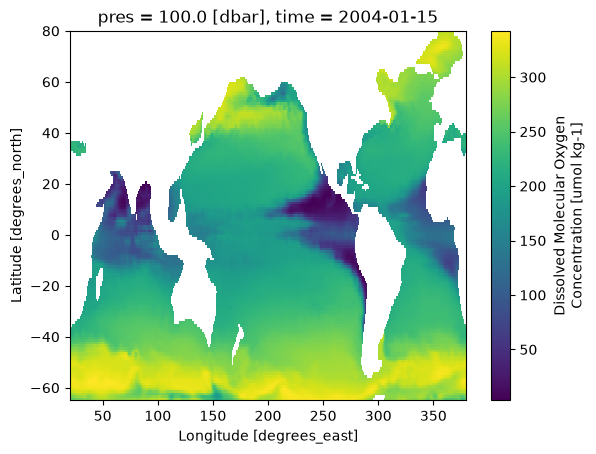

In [10]:
%%time
published.oxy.isel(time=0, pres=10).plot()

CPU times: user 81.1 ms, sys: 41.3 ms, total: 122 ms
Wall time: 847 ms


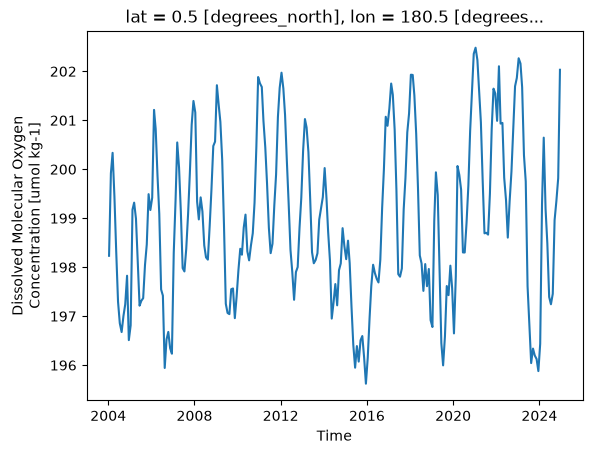

In [11]:
%%time
published.oxy.sel(
    lat=0,
    lon=180,
    pres=published.pres.isel(pres=0),
    method="nearest",
).plot()

### Assertions

Shape, variables, key metadata, dtypes and the requested chunk shapes, plus a sample of
actual values compared against the source. `isel` with index lists reads a handful of
points, not the arrays — neither dataset is materialized here.

In [12]:
assert dict(published.sizes) == dict(ds.sizes)
assert set(published.data_vars) == set(ds.data_vars)
assert published.attrs["product_version"] == "2.3"
assert published.attrs["doi"] == "10.25921/z72m-yz67"
assert "CF-" in published.attrs["Conventions"]
assert published.attrs["license"].startswith("Creative Commons Zero v1.0 Universal (CC0 1.0)")

for name in ds.variables:
    assert published[name].dtype == ds[name].dtype, name
    expected_chunks = encoding[name]["chunks"]
    actual_chunks = tuple(published[name].encoding["chunks"])
    assert actual_chunks == expected_chunks, (name, actual_chunks, expected_chunks)

# Compare values at a scatter of points. Re-open the source *unchunked*: with dask chunks
# each of these points drags in a whole (14, 2, 73, 120) chunk, and because the source is
# contiguous and uncompressed that is thousands of strided reads per chunk — minutes over
# HTTPS. chunks=None lets netCDF4 fetch only the elements asked for.
sample = {"time": [0, 126, 251], "pres": [0, 29, 57], "lat": [0, 72, 144], "lon": [0, 179, 359]}
source_points = xr.open_dataset(source, chunks=None, engine="netcdf4")
source_sample = source_points[list(source_points.data_vars)].isel(sample).load()
published_sample = published[list(source_points.data_vars)].isel(sample).load()
xr.testing.assert_allclose(published_sample, source_sample)

print("Validation passed")

Validation passed


## 7. Mirror the docs to the store root

A reader who finds the store on Source Cooperative should find the README, the pins, the
helper module and this notebook next to it. They go to the `gobai-o2/` root, alongside the
`monthly/` repository directory. `path.name` flattens the `../` paths onto that root.

Mirror **only from merged `main`** — uploading from a branch is how the published copies
drift out of step with git.

In [13]:
RUN_MIRROR = False  # True uploads the docs listed below to s3://fish-pace/gobai-o2/

if RUN_MIRROR:
    import boto3

    source_creds, _ = get_source_credentials()
    s3 = boto3.client(
        "s3",
        endpoint_url=source_creds["endpoint_url"],
        region_name=source_creds["region_name"],
        aws_access_key_id=source_creds["aws_access_key_id"],
        aws_secret_access_key=source_creds["aws_secret_access_key"],
        aws_session_token=source_creds.get("aws_session_token"),
    )

    for local_file in ["README.md", "requirements.txt",
                       "gobai-o2-monthly-icechunk-sc.ipynb", "../icechunk_utils.py"]:
        path = Path(local_file)
        if not path.is_file():
            raise FileNotFoundError(f"File not found: {path}")
        key = f"gobai-o2/{path.name}"
        s3.upload_file(Filename=str(path), Bucket=BUCKET, Key=key)
        print(f"Uploaded {path} -> s3://{BUCKET}/{key}")
else:
    print("RUN_MIRROR is False — nothing uploaded.")

RUN_MIRROR is False — nothing uploaded.
